# NARMA-10: Nonlinear AutoRegressive Moving Average Task

## Background

NARMA-N is the **canonical benchmark for measuring reservoir memory and nonlinear processing capacity**. Unlike Mackey-Glass (which is a real dynamical system), NARMA is a synthetic task designed specifically to stress-test temporal learning systems.

It was introduced by Atiya & Parlos (2000) and has been used to benchmark virtually every reservoir computing architecture, including:

- Fujii & Nakajima (2020) -- *QRC for near-term quantum devices* (NARMA-10)
- Nakajima (2019) -- *Spatial multiplexing QRC*
- Tran & Nakajima (2020) -- *Higher order QRC* (NARMA-10 and NARMA-20)
- Tanaka et al. (2019) -- *Physical reservoir computing review*

## The Recurrence

NARMA order N is defined by:

$$y(t+1) = \alpha * y(t)
       + \beta  * y(t) * \sum_{i=0}^{N-1} y(t-i)
       + \gamma * u(t-N+1) * u(t)
       + \delta$$

where u(t) is i.i.d. uniform noise in [0, 0.5].

Standard parameters:

| Param | Value | Meaning |
|-------|-------|--------|
| alpha | 0.3   | recurrence on y(t) |
| beta  | 0.05  | nonlinear coupling term |
| gamma | 1.5   | input coupling |
| delta | 0.1   | bias |
| N     | 10    | memory depth (NARMA-10 is standard) |

## Why it is ideal for QRC

1. **Memory test**: y(t+1) depends on the last N values of y -- the reservoir must remember N steps
2. **Nonlinearity test**: the product y(t)*sum(y) and u(t-N)*u(t) require nonlinear combinations
3. **Controlled difficulty**: increase N to increase required memory and difficulty
4. **No measurement noise**: u(t) is the only randomness; given u, y is deterministic
5. **Direct QRC relevance**: Fujii & Nakajima use this to show quantum systems outperform classical ESN

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

np.random.seed(42)

## Generate NARMA Series

In [2]:
def narma(T=10000, order=10, alpha=0.3, beta=0.05, gamma=1.5, delta=0.1, seed=42):
    """
    Generate a NARMA-N time series.

    The task: given input sequence u(t), predict the output y(t+1).
    Output depends on the last `order` values of y and u -- testing memory depth.

    Parameters
    ----------
    T     : number of timesteps
    order : NARMA order (memory depth); 10 is standard
    alpha : recurrence weight on y(t)
    beta  : nonlinear coupling strength
    gamma : input coupling
    delta : constant bias
    seed  : random seed for reproducibility

    Returns
    -------
    u : np.ndarray, shape (T,)  -- input (uniform noise)
    y : np.ndarray, shape (T,)  -- target output
    """
    rng = np.random.default_rng(seed)
    u = rng.uniform(0, 0.5, size=T)
    y = np.zeros(T)

    # Initialise first `order` steps
    y[:order] = 0.0

    for t in range(order, T - 1):
        y[t + 1] = (
            alpha * y[t]
            + beta * y[t] * np.sum(y[t - order + 1 : t + 1])
            + gamma * u[t - order + 1] * u[t]
            + delta
        )
        # Clip to avoid divergence (rare with standard params but good practice)
        y[t + 1] = np.clip(y[t + 1], 0, 1)

    return u, y

In [3]:
u10, y10 = narma(T=10000, order=10)
u20, y20 = narma(T=10000, order=20)

print(f'NARMA-10: u range [{u10.min():.3f}, {u10.max():.3f}]  y range [{y10.min():.3f}, {y10.max():.3f}]')
print(f'NARMA-20: u range [{u20.min():.3f}, {u20.max():.3f}]  y range [{y20.min():.3f}, {y20.max():.3f}]')

NARMA-10: u range [0.000, 0.500]  y range [0.000, 0.901]
NARMA-20: u range [0.000, 0.500]  y range [0.000, 1.000]


## Visualisation

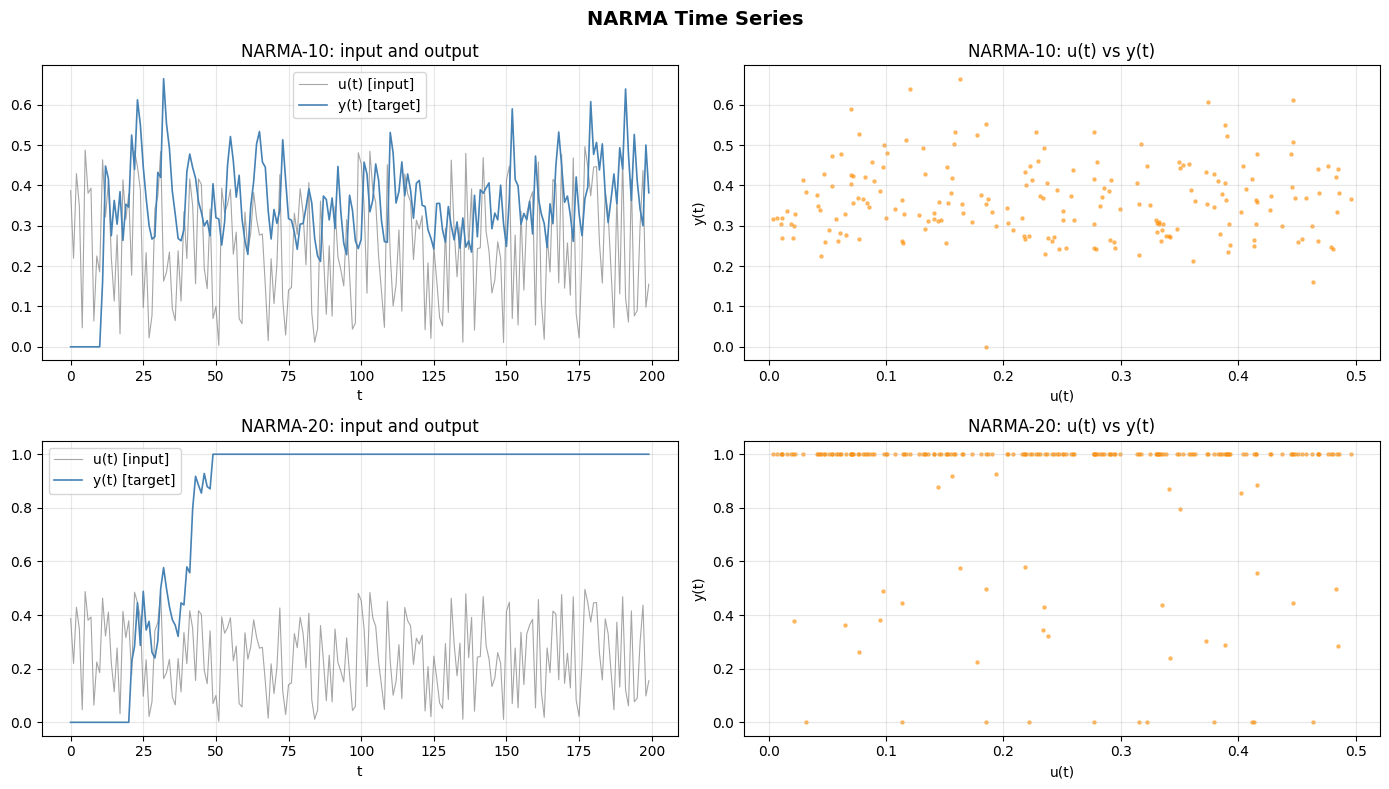

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('NARMA Time Series', fontsize=14, fontweight='bold')

t_plot = np.arange(200)

for row, (u, y, order) in enumerate([(u10, y10, 10), (u20, y20, 20)]):
    axes[row, 0].plot(t_plot, u[t_plot], label='u(t) [input]', color='gray', lw=0.8, alpha=0.7)
    axes[row, 0].plot(t_plot, y[t_plot], label='y(t) [target]', color='steelblue', lw=1.2)
    axes[row, 0].set_title(f'NARMA-{order}: input and output')
    axes[row, 0].set_xlabel('t')
    axes[row, 0].legend()
    axes[row, 0].grid(True, alpha=0.3)

    axes[row, 1].scatter(u[10:210], y[10:210], s=5, alpha=0.5, color='darkorange')
    axes[row, 1].set_title(f'NARMA-{order}: u(t) vs y(t)')
    axes[row, 1].set_xlabel('u(t)')
    axes[row, 1].set_ylabel('y(t)')
    axes[row, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('narma_plots.png', dpi=150, bbox_inches='tight')
plt.show()

## Train / Validation / Test Split

The reservoir receives u(t) and must predict y(t+1).
Discard the first `order` steps as they are the initialisation transient.

In [5]:
ORDER = 10
TRAIN, VAL, TEST = 5000, 1000, 2000

# Input to reservoir: u(t); target: y(t+1)
u_input  = u10[ORDER:-1]   # u(t) from t=10 to T-2
y_target = y10[ORDER+1:]   # y(t+1)

u_train, y_train = u_input[:TRAIN],        y_target[:TRAIN]
u_val,   y_val   = u_input[TRAIN:TRAIN+VAL], y_target[TRAIN:TRAIN+VAL]
u_test,  y_test  = u_input[TRAIN+VAL:TRAIN+VAL+TEST], y_target[TRAIN+VAL:TRAIN+VAL+TEST]

print(f'Train: {u_train.shape}  |  Val: {u_val.shape}  |  Test: {u_test.shape}')

Train: (5000,)  |  Val: (1000,)  |  Test: (2000,)


## NRMSE Evaluation

In [6]:
def nrmse(y_true, y_pred):
    return float(np.sqrt(np.mean((y_pred - y_true) ** 2) / np.var(y_true)))

# Naive baseline: predict the mean of training targets
nrmse_mean = nrmse(y_test, np.full_like(y_test, y_train.mean()))
print(f'Mean-prediction NRMSE: {nrmse_mean:.4f}  (= 1.0 by definition)')

# Published QRC results (Fujii & Nakajima 2020, Table 1):
print()
print('Published NARMA-10 NRMSE benchmarks (from QRC papers):')
print('  Classical ESN (100 nodes) : ~0.20')
print('  QRC (5 qubits, 5 steps)   : ~0.15')
print('  QRC (5 qubits, 50 steps)  : ~0.12')

Mean-prediction NRMSE: 1.0013  (= 1.0 by definition)

Published NARMA-10 NRMSE benchmarks (from QRC papers):
  Classical ESN (100 nodes) : ~0.20
  QRC (5 qubits, 5 steps)   : ~0.15
  QRC (5 qubits, 50 steps)  : ~0.12


## Memory Capacity Analysis

The **memory capacity (MC)** measures how well a reservoir can reconstruct delayed inputs.
It quantifies how many past timesteps the reservoir can remember.

In [7]:
def memory_capacity_task(u, max_delay=20):
    """
    Generate (input, delayed_output) pairs for delays 1..max_delay.
    Used to evaluate reservoir memory without training a full model.
    Target for delay k: y(t) = u(t-k).
    """
    tasks = {}
    for k in range(1, max_delay + 1):
        tasks[k] = {
            'input': u[k:],
            'target': u[:-k]
        }
    return tasks


mc_tasks = memory_capacity_task(u10, max_delay=20)
print('Memory capacity tasks created for delays 1-20.')
print('To compute MC for your reservoir: train linear readout for each delay,')
print('compute R^2 (squared Pearson correlation), then MC = sum_k R^2(k).')

Memory capacity tasks created for delays 1-20.
To compute MC for your reservoir: train linear readout for each delay,
compute R^2 (squared Pearson correlation), then MC = sum_k R^2(k).


## Save Datasets to CSV

In [ ]:
# Full series
pd.DataFrame({'u': u10, 'y': y10}).to_csv('narma10_full.csv', index_label='t')
pd.DataFrame({'u': u20, 'y': y20}).to_csv('narma20_full.csv', index_label='t')

# Split datasets for NARMA-10
for name, u, y in [('train', u_train, y_train), ('val', u_val, y_val), ('test', u_test, y_test)]:
    pd.DataFrame({'u_t': u, 'y_t1': y}).to_csv(f'narma10_{name}.csv', index=False)

print('Saved: narma10_full.csv, narma20_full.csv')
print('Saved: narma10_train/val/test.csv')

Saved: narma10_full.csv, narma20_full.csv
Saved: narma10_train/val/test.csv


: 

## Using This Task in QRC

```python
# QRC for NARMA-10 (pseudocode)
for t, u_t in enumerate(u_train):
    rho = encode_input(u_t, n_qubits=N)   # e.g. Rx rotation by pi*u_t
    rho = U_reservoir @ rho @ U_reservoir.conj().T  # fixed unitary evolution
    features[t] = [expectation(rho, sigma_z(i)) for i in range(N)]

# Fit linear readout (ridge regression)
from sklearn.linear_model import Ridge
clf = Ridge(alpha=1e-6)
clf.fit(features, y_train)

y_pred = clf.predict(features_test)
print(f'NARMA-10 NRMSE: {nrmse(y_test, y_pred):.4f}')
```

Key references for NARMA benchmarks in your collection:
- Fujii & Nakajima (2020): NARMA-10 benchmark Table 1
- Tran & Nakajima (2020): Higher-order QRC on NARMA-10 and NARMA-20
- Nakajima (2019): Spatial multiplexing for improved NARMA scores